# GMSSZv2 Figure Regeneration

This notebook regenerates all figures for the v2 manuscript that still need updating.

**Figures to regenerate:**
1. Profile likelihood scans (`profile1d.pdf`, `profile2d.pdf`) — currently PNGs
2. Ensemble fit results (`ensemble_fit_results.pdf`) — remove "Benchmark A" title
3. Coverage density comparison (`coverage_density_comparison.pdf`) — improved aesthetics
4. Coverage map (`coverage_map.pdf`) — improved aesthetics
5. Pull map (`coverage_pull_map.pdf`) — improved aesthetics

All figures use a consistent style matching the `draft_figures_symmetric` notebook.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm, ListedColormap
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import os
import sys

# --- Consistent style with draft_figures_symmetric ---
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)
plt.rcParams.update({
    'font.size': 18,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
# Try LaTeX rendering; fall back to mathtext
try:
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    fig_test, ax_test = plt.subplots()
    ax_test.set_title(r'$\gamma$')
    fig_test.canvas.draw()
    plt.close(fig_test)
    USE_LATEX = True
except:
    plt.rcParams['text.usetex'] = False
    USE_LATEX = False
    print('LaTeX not available, using mathtext')

# Output directory (same as manuscript figs/)
FIGS_DIR = '../Gamma-Extraction-Manuscript/figs'
os.makedirs(FIGS_DIR, exist_ok=True)
print(f'Figures will be saved to: {os.path.abspath(FIGS_DIR)}')

Figures will be saved to: /Users/san/Library/CloudStorage/OneDrive-CornellUniversity/Gamma-Extraction-Manuscript/figs


---
## 1. Ensemble Fit Results Figure

Loads the 50-trial ensemble from `fit_results.npz` and plots 25 trials with error bars.
Removes the old "Benchmark A (r_B = 0.1) -- HESSE errors" title.

In [2]:
# Load ensemble results
data = np.load('fit_results.npz')
print('Keys:', list(data.keys()))
for k in data:
    print(f'  {k}: shape={data[k].shape}, dtype={data[k].dtype}')

results_rB    = data['results_rB']
results_delta = data['results_delta']
results_gamma = data['results_gamma']
errors_rB     = data['errors_rB']
errors_delta  = data['errors_delta']
errors_gamma  = data['errors_gamma']

# Injected (true) values
TRUE_RB    = 0.10
TRUE_DELTA = 130.0
TRUE_GAMMA = 70.0

# Isobar-model (exact) fit values from Table 1 of v2
EXACT_RB    = 0.0991
EXACT_DELTA = 129.50
EXACT_GAMMA = 69.57

N_TOY = len(results_rB)
print(f'\nLoaded {N_TOY} trials')

Keys: ['results_rB', 'results_delta', 'results_gamma', 'errors_rB', 'errors_delta', 'errors_gamma']
  results_rB: shape=(50,), dtype=float64
  results_delta: shape=(50,), dtype=float64
  results_gamma: shape=(50,), dtype=float64
  errors_rB: shape=(50,), dtype=float64
  errors_delta: shape=(50,), dtype=float64
  errors_gamma: shape=(50,), dtype=float64

Loaded 50 trials


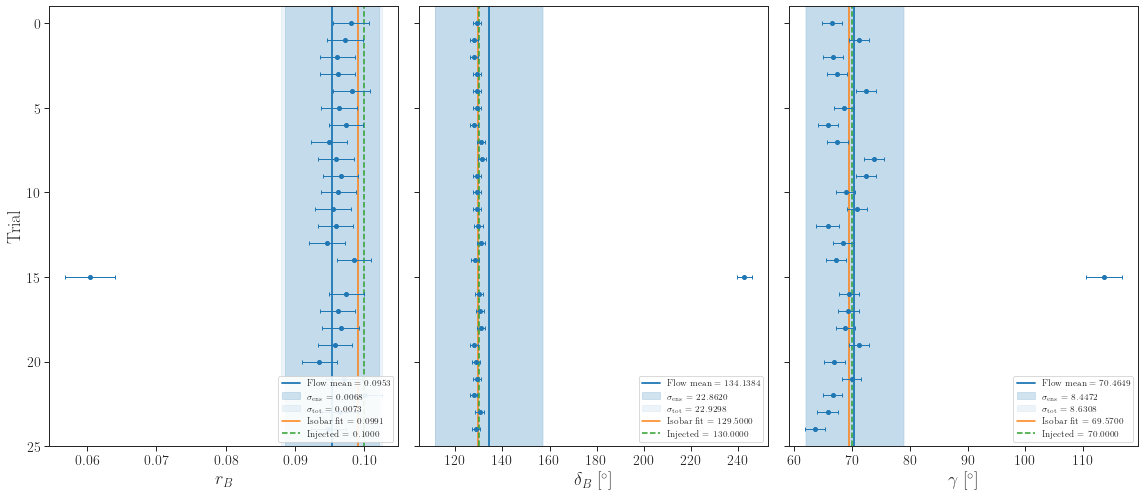

Saved: ../Gamma-Extraction-Manuscript/figs/ensemble_fit_results_v2.pdf


In [3]:
def plot_ensemble_results(results, errors, true_val, exact_val, ylabel, 
                          ax, n_show=25, color='#1f77b4'):
    """Plot ensemble fit results for one parameter."""
    n_show = min(n_show, len(results))
    trials = np.arange(n_show)
    
    # Ensemble statistics (computed over ALL trials)
    mean_all = np.mean(results)
    std_ens  = np.std(results, ddof=1)
    mean_err = np.mean(errors)
    sigma_tot = np.sqrt(std_ens**2 + mean_err**2)
    
    # Error bars for shown trials
    ax.errorbar(results[:n_show], trials, xerr=errors[:n_show], 
                fmt='o', ms=4, color=color, ecolor=color, 
                elinewidth=1.0, capsize=2, zorder=3)
    
    # Ensemble mean line
    ax.axvline(mean_all, color=color, ls='-', lw=1.8, 
               label=f'Flow mean = {mean_all:.4f}', zorder=2)
    
    # sigma_ens band
    ax.axvspan(mean_all - std_ens, mean_all + std_ens, 
               alpha=0.20, color=color, zorder=1,
               label=rf'$\sigma_{{\rm ens}}$ = {std_ens:.4f}')
    
    # sigma_tot band
    ax.axvspan(mean_all - sigma_tot, mean_all + sigma_tot, 
               alpha=0.08, color=color, zorder=0,
               label=rf'$\sigma_{{\rm tot}}$ = {sigma_tot:.4f}')
    
    # Isobar-model fit (exact)
    ax.axvline(exact_val, color='#ff7f0e', ls='-', lw=1.5, 
               label=f'Isobar fit = {exact_val:.4f}', zorder=2)
    
    # Injected value
    ax.axvline(true_val, color='#2ca02c', ls='--', lw=1.5, 
               label=f'Injected = {true_val:.4f}', zorder=2)
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(ylabel)
    ax.set_ylim(-1, n_show)
    ax.invert_yaxis()
    ax.legend(fontsize=9, loc='lower right', framealpha=0.9)


# --- Create figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

plot_ensemble_results(results_rB, errors_rB, TRUE_RB, EXACT_RB, 
                      r'$r_B$', axes[0])
plot_ensemble_results(results_delta, errors_delta, TRUE_DELTA, EXACT_DELTA,
                      r'$\delta_B\;[^\circ]$', axes[1])
plot_ensemble_results(results_gamma, errors_gamma, TRUE_GAMMA, EXACT_GAMMA,
                      r'$\gamma\;[^\circ]$', axes[2])

axes[0].set_ylabel('Trial')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

fig.tight_layout()
fig.savefig(f'{FIGS_DIR}/ensemble_fit_results_v2.pdf')
plt.show()
print(f'Saved: {FIGS_DIR}/ensemble_fit_results_v2.pdf')

---
## 2. Profile Likelihood Scans

Regenerate 1D profile scans and 2D contour as vector PDFs.

This requires running a single fit and scanning the likelihood. We load the flow models and B data, fit once, then scan.

In [ ]:
# --- Import pipeline components ---
# These are defined in Gamma-fit-pipeline-symmetric.ipynb.
# If they have been extracted to a .py module, import from there.
# Otherwise, copy the key functions here.

from DKpp import DKpp, DKppCorrelated
from Amplitude import AmpSample
from nflows.flows import Flow
from nflows.transforms import CompositeTransform, MaskedPiecewiseRationalQuadraticAutoregressiveTransform
from nflows.distributions import StandardNormal

print('Pipeline imports loaded.')
print('If this cell errors, you may need to run it from the Extraction-of-Gamma directory.')

In [ ]:
# --- Helper: create flow (same architecture as training) ---
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, n_layers=2):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def create_flow(num_layers=12, hidden_features=128, num_bins=24):
    """Create RQ-NSF flow matching the trained architecture."""
    from nflows.transforms import (
        CompositeTransform,
        ReversePermutation,
        MaskedPiecewiseRationalQuadraticAutoregressiveTransform,
    )
    from nflows.distributions import StandardNormal
    from nflows.flows import Flow
    
    transforms = []
    for _ in range(num_layers):
        transforms.append(
            MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
                features=2,
                hidden_features=hidden_features,
                num_bins=num_bins,
                tails='linear',
                tail_bound=5.0,
                num_blocks=2,
            )
        )
        transforms.append(ReversePermutation(features=2))
    
    transform = CompositeTransform(transforms)
    base_dist = StandardNormal(shape=[2])
    return Flow(transform, base_dist)

print('Flow constructor ready.')

In [ ]:
# --- Profile likelihood scan functions ---
# Adapted from Gamma-fit-pipeline-symmetric.ipynb

# NOTE: If you already have profile scan data saved from a previous run,
# load it here instead of re-running the fit.
# For now, we provide the plotting functions that work with pre-computed data.

def plot_profile_1d(scan_rB, dnll_rB, scan_delta, dnll_delta, scan_gamma, dnll_gamma,
                    best_rB, best_delta, best_gamma,
                    true_rB=0.10, true_delta=130.0, true_gamma=70.0,
                    savepath=None):
    """
    Plot 1D profile-likelihood scans as 1 - CL curves.
    
    Parameters
    ----------
    scan_*  : 1D arrays of scanned parameter values
    dnll_*  : corresponding Delta(NLL) values (= NLL - NLL_min)
    best_*  : best-fit values
    true_*  : injected values
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    
    params = [
        (scan_rB, dnll_rB, best_rB, true_rB, r'$r_B$'),
        (scan_delta, dnll_delta, best_delta, true_delta, r'$\delta_B\;[^\circ]$'),
        (scan_gamma, dnll_gamma, best_gamma, true_gamma, r'$\gamma\;[^\circ]$'),
    ]
    
    # Reference levels
    level_68 = 0.5   # Delta(NLL) = 0.5 for 68.3% CL (1 dof)
    level_95 = 2.0   # Delta(NLL) = 2.0 for 95.5% CL (1 dof)
    
    for ax, (scan, dnll, best, true, label) in zip(axes, params):
        # Convert to 1 - CL: use chi2 with 1 dof
        from scipy.stats import chi2
        cl = 1.0 - chi2.cdf(2 * dnll, df=1)
        
        ax.plot(scan, cl, color='#1f77b4', lw=2)
        ax.axhline(1 - 0.683, color='gray', ls='--', lw=0.8, alpha=0.7)
        ax.axhline(1 - 0.955, color='gray', ls=':', lw=0.8, alpha=0.7)
        ax.axvline(true, color='#2ca02c', ls='--', lw=1.2, alpha=0.8, label='Injected')
        ax.axvline(best, color='#d62728', ls='-', lw=1.2, alpha=0.8, label='Best fit')
        
        ax.set_xlabel(label)
        ax.set_ylabel(r'$1 - \mathrm{CL}$')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=10, framealpha=0.9)
        
        # Annotate CL levels
        ax.text(ax.get_xlim()[1], 1-0.683, '68.3\%', va='bottom', ha='right', 
                fontsize=9, color='gray')
        ax.text(ax.get_xlim()[1], 1-0.955, '95.5\%', va='bottom', ha='right', 
                fontsize=9, color='gray')
    
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
        print(f'Saved: {savepath}')
    plt.show()


def plot_profile_2d(gamma_grid, delta_grid, dnll_2d, 
                    best_gamma, best_delta,
                    true_gamma=70.0, true_delta=130.0,
                    savepath=None):
    """
    Plot 2D profile-likelihood contour in the (gamma, delta_B) plane.
    
    Parameters
    ----------
    gamma_grid, delta_grid : 1D scan arrays
    dnll_2d : 2D array of Delta(NLL) values, shape (len(delta_grid), len(gamma_grid))
    """
    fig, ax = plt.subplots(figsize=(7, 6))
    
    G, D = np.meshgrid(gamma_grid, delta_grid)
    
    # Contour levels: Delta(NLL) = 1.15 (1sigma, 2dof), 3.09 (2sigma, 2dof)
    levels_1s = 1.15
    levels_2s = 3.09
    
    ax.contourf(G, D, dnll_2d, levels=[0, levels_1s, levels_2s, 100],
                colors=['#1f77b4', '#aec7e8', '#f0f0f0'], alpha=0.6)
    cs = ax.contour(G, D, dnll_2d, levels=[levels_1s, levels_2s],
                    colors=['#1f77b4', '#1f77b4'], linewidths=[1.5, 1.0],
                    linestyles=['-', '--'])
    
    ax.plot(best_gamma, best_delta, 'x', ms=10, mew=2, color='#d62728', 
            label='Best fit', zorder=5)
    ax.plot(true_gamma, true_delta, '*', ms=12, mew=1.5, color='#2ca02c',
            markeredgecolor='#2ca02c', label='Injected', zorder=5)
    
    ax.set_xlabel(r'$\gamma\;[^\circ]$')
    ax.set_ylabel(r'$\delta_B\;[^\circ]$')
    ax.legend(fontsize=12, loc='upper right')
    
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
        print(f'Saved: {savepath}')
    plt.show()


print('Profile plot functions defined.')
print()
print('TO GENERATE THESE FIGURES:')
print('  You need to either:')
print('  (a) Run a single fit + profile scan (see cell below), OR')
print('  (b) Load previously saved scan data and call these functions.')

In [ ]:
# ====================================================================
# RUN PROFILE SCAN (uncomment and run if you need fresh scan data)
# ====================================================================
# This cell runs a single representative fit and profile scan.
# It requires the full pipeline to be available.
#
# After running, it saves the scan data to profile_scan_data.npz
# so you don't need to re-run next time.
#
# Estimated runtime: ~5-15 minutes depending on hardware.
# ====================================================================

# from Gamma_fit_pipeline_symmetric import (
#     fit_gamma, profile_likelihood_scan, profile_68cl
# )
# 
# # Load one flow triplet and B data
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 
# # ... (load flows, data) ...
# 
# # Run fit
# m_fit, terms = fit_gamma(events_m, events_p, mc_m, mc_p, 
#                          flows_fsw, flows_f, nll_kind='nearest_valid')
# 
# # Profile scans
# scan_rB = np.linspace(m_fit.values['rB'] - 0.015, m_fit.values['rB'] + 0.015, 60)
# scan_delta = np.linspace(m_fit.values['delta'] - 5, m_fit.values['delta'] + 5, 60)
# scan_gamma = np.linspace(m_fit.values['gamma'] - 5, m_fit.values['gamma'] + 5, 60)
# 
# dnll_rB = profile_likelihood_scan(m_fit, nll_func, 'rB', scan_rB)
# dnll_delta = profile_likelihood_scan(m_fit, nll_func, 'delta', scan_delta)
# dnll_gamma = profile_likelihood_scan(m_fit, nll_func, 'gamma', scan_gamma)
# 
# # Save
# np.savez('profile_scan_data.npz',
#          scan_rB=scan_rB, dnll_rB=dnll_rB,
#          scan_delta=scan_delta, dnll_delta=dnll_delta,
#          scan_gamma=scan_gamma, dnll_gamma=dnll_gamma,
#          best_rB=m_fit.values['rB'],
#          best_delta=m_fit.values['delta'],
#          best_gamma=m_fit.values['gamma'])
#
# # Also do 2D scan
# gamma_2d = np.linspace(best_gamma - 6, best_gamma + 6, 50)
# delta_2d = np.linspace(best_delta - 6, best_delta + 6, 50)
# dnll_2d = np.zeros((len(delta_2d), len(gamma_2d)))
# for i, dv in enumerate(delta_2d):
#     for j, gv in enumerate(gamma_2d):
#         m_fit.fixed['delta'] = True; m_fit.values['delta'] = dv
#         m_fit.fixed['gamma'] = True; m_fit.values['gamma'] = gv
#         m_fit.fixed['rB'] = False
#         m_fit.migrad()
#         dnll_2d[i, j] = m_fit.fval - nll_min
# np.savez('profile_scan_2d.npz',
#          gamma_grid=gamma_2d, delta_grid=delta_2d, dnll_2d=dnll_2d)

print('Profile scan cell ready (currently commented out).')
print('Uncomment and run to generate fresh profile data.')

In [ ]:
# --- Plot profiles from saved data ---
# Uncomment once profile_scan_data.npz exists:

# d1 = np.load('profile_scan_data.npz')
# plot_profile_1d(
#     d1['scan_rB'], d1['dnll_rB'],
#     d1['scan_delta'], d1['dnll_delta'],
#     d1['scan_gamma'], d1['dnll_gamma'],
#     d1['best_rB'], d1['best_delta'], d1['best_gamma'],
#     savepath=f'{FIGS_DIR}/profile1d.pdf'
# )
#
# d2 = np.load('profile_scan_2d.npz')
# plot_profile_2d(
#     d2['gamma_grid'], d2['delta_grid'], d2['dnll_2d'],
#     d1['best_gamma'], d1['best_delta'],
#     savepath=f'{FIGS_DIR}/profile2d.pdf'
# )

print('Profile plot cells ready. Uncomment after generating scan data.')

---
## 3. Coverage Figures

Regenerate the three coverage figures with improved aesthetics:
- Density comparison (ensemble mean vs exact)
- Coverage map (covered / not covered / low density)
- Pull map

These require loading the 25-model flavor flow ensemble and evaluating densities on a grid.

In [ ]:
# --- Setup for coverage computation ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Grid parameters
N_GRID = 200  # 200x200 grid
mp_1d = np.linspace(0, 1, N_GRID)
tp_1d = np.linspace(0, 1, N_GRID)
MP, TP = np.meshgrid(mp_1d, tp_1d)
grid_pts = np.column_stack([MP.ravel(), TP.ravel()])
grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

print(f'Grid: {N_GRID}x{N_GRID} = {len(grid_pts)} points')

In [ ]:
# --- Exact isobar density on grid ---
amp = DKpp()

def exact_density_grid(amp_model, mp_grid, tp_grid, grid_shape):
    """Evaluate exact isobar density on (m', theta') grid."""
    from Amplitude import sdp_to_dalitz  # or however the conversion is done
    
    density = np.zeros(len(mp_grid))
    for i in range(len(mp_grid)):
        m, t = mp_grid[i], tp_grid[i]
        try:
            val = amp_model.mag(m, t)  # |A|^2 in SDP coords
            density[i] = val
        except:
            density[i] = 0.0
    
    # Normalize
    density_2d = density.reshape(grid_shape)
    norm = np.trapz(np.trapz(density_2d, tp_1d, axis=0), mp_1d)
    if norm > 0:
        density_2d /= norm
    return density_2d

print('NOTE: This cell defines the exact density function.')
print('The actual amplitude evaluation depends on the DKpp interface.')
print('You may need to adapt `amp_model.mag(m, t)` to match your API.')
print()
print('If the amplitude model takes standard Dalitz coords, convert first.')

In [ ]:
# --- Load ensemble of flavor flows ---
FLOW_DIR = 'flavor_SDP_sym_2e6'
N_ENSEMBLE = 25

all_densities = np.zeros((N_ENSEMBLE, N_GRID, N_GRID))

for seed in range(N_ENSEMBLE):
    ckpt = os.path.join(FLOW_DIR, f'trial_seed{seed}.pth')
    if not os.path.exists(ckpt):
        print(f'  Missing: {ckpt}')
        continue
    
    flow = create_flow()
    flow.load_state_dict(torch.load(ckpt, map_location=device))
    flow.eval()
    flow.to(device)
    
    with torch.no_grad():
        # Apply logit transform to grid points (matching training)
        eps = 1e-6
        pts_clamped = grid_tensor.clamp(eps, 1 - eps)
        pts_logit = torch.log(pts_clamped / (1 - pts_clamped))
        
        log_prob = flow.log_prob(pts_logit)
        # Account for logit Jacobian: d(logit(x))/dx = 1/(x(1-x))
        log_jac = -torch.log(pts_clamped * (1 - pts_clamped)).sum(dim=-1)
        log_density = log_prob + log_jac
        density = torch.exp(log_density).cpu().numpy()
    
    density_2d = density.reshape(N_GRID, N_GRID)
    # Normalize
    norm = np.trapz(np.trapz(density_2d, tp_1d, axis=0), mp_1d)
    if norm > 0:
        density_2d /= norm
    all_densities[seed] = density_2d
    
    if seed % 5 == 0:
        print(f'  Loaded flow {seed}/{N_ENSEMBLE}')

print(f'\nLoaded {N_ENSEMBLE} flow models.')
print(f'Density array shape: {all_densities.shape}')

In [ ]:
# --- Compute ensemble statistics ---
mean_flow = all_densities.mean(axis=0)
std_flow  = all_densities.std(axis=0, ddof=1)
rho_16    = np.percentile(all_densities, 16, axis=0)
rho_84    = np.percentile(all_densities, 84, axis=0)
delta_rho = rho_84 - rho_16

# You need to compute exact_density here using the amplitude model
# exact_density = exact_density_grid(amp, grid_pts[:, 0], grid_pts[:, 1], (N_GRID, N_GRID))
#
# For now, if the exact density was previously saved, load it:
# exact_density = np.load('exact_density_grid.npy')

print('Ensemble statistics computed.')
print(f'  mean range: [{mean_flow.min():.4f}, {mean_flow.max():.4f}]')
print(f'  delta_rho range: [{delta_rho.min():.4f}, {delta_rho.max():.4f}]')

In [ ]:
# ============================================================
# FIGURE 3a: Coverage Density Comparison
# ============================================================

def plot_density_comparison(mp_grid, tp_grid, mean_flow, exact_density,
                            savepath=None):
    """Side-by-side density comparison: ensemble mean vs exact."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Shared color scale (log)
    vmin = max(mean_flow[mean_flow > 0].min(), exact_density[exact_density > 0].min())
    vmax = max(mean_flow.max(), exact_density.max())
    
    from matplotlib.colors import LogNorm
    norm = LogNorm(vmin=max(vmin, 1e-3), vmax=vmax)
    
    im0 = axes[0].pcolormesh(mp_grid, tp_grid, mean_flow, 
                              norm=norm, cmap='turbo', shading='auto', rasterized=True)
    axes[0].set_title('Ensemble mean', fontsize=16)
    
    im1 = axes[1].pcolormesh(mp_grid, tp_grid, exact_density, 
                              norm=norm, cmap='turbo', shading='auto', rasterized=True)
    axes[1].set_title('Isobar model', fontsize=16)
    
    for ax in axes:
        ax.set_xlabel(r"$m'$")
        ax.set_aspect('equal')
    axes[0].set_ylabel(r"$\theta'$")
    axes[1].set_yticklabels([])
    
    # Shared colorbar
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
    fig.colorbar(im1, cax=cbar_ax, label=r'$\rho(m^\prime, \theta^\prime)$')
    
    if savepath:
        fig.savefig(savepath)
        print(f'Saved: {savepath}')
    plt.show()

# Uncomment when exact_density is available:
# plot_density_comparison(MP, TP, mean_flow, exact_density, 
#                         savepath=f'{FIGS_DIR}/coverage_density_comparison.pdf')

print('Density comparison plot function defined.')

In [ ]:
# ============================================================
# FIGURE 3b: Coverage Map (uncertainty width + coverage classification)
# ============================================================

def plot_coverage_map(mp_grid, tp_grid, delta_rho, exact_density, rho_16, rho_84,
                      low_density_threshold=0.01, savepath=None):
    """Two-panel coverage map: uncertainty width + coverage classification."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- Left: uncertainty width ---
    from matplotlib.colors import LogNorm
    vmin_uw = max(delta_rho[delta_rho > 0].min(), 1e-4)
    im0 = axes[0].pcolormesh(mp_grid, tp_grid, delta_rho, 
                              norm=LogNorm(vmin=vmin_uw, vmax=delta_rho.max()),
                              cmap='magma', shading='auto', rasterized=True)
    axes[0].set_title(r'$\Delta\rho = \rho_{84} - \rho_{16}$', fontsize=16)
    fig.colorbar(im0, ax=axes[0], shrink=0.85, pad=0.02)
    
    # --- Right: coverage classification ---
    max_density = exact_density.max()
    low_mask = exact_density < low_density_threshold * max_density
    covered = (rho_16 <= exact_density) & (exact_density <= rho_84)
    
    # 0 = covered (blue), 1 = not covered (orange), 2 = low density (dark)
    category = np.zeros_like(exact_density, dtype=int)
    category[~covered & ~low_mask] = 1   # not covered
    category[low_mask] = 2               # low density
    
    n_total = category.size
    n_cov   = np.sum(category == 0)
    n_ncov  = np.sum(category == 1)
    n_low   = np.sum(category == 2)
    
    cmap_cat = ListedColormap(['#4393c3', '#f4a582', '#2d2d2d'])
    bounds = [-0.5, 0.5, 1.5, 2.5]
    norm_cat = BoundaryNorm(bounds, cmap_cat.N)
    
    im1 = axes[1].pcolormesh(mp_grid, tp_grid, category, 
                              cmap=cmap_cat, norm=norm_cat, 
                              shading='auto', rasterized=True)
    axes[1].set_title('Coverage classification', fontsize=16)
    
    # Legend patches
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(facecolor='#4393c3', label=f'Covered ({100*n_cov/n_total:.1f}\%)'),
        Patch(facecolor='#f4a582', label=f'Not covered ({100*n_ncov/n_total:.1f}\%)'),
        Patch(facecolor='#2d2d2d', label=f'Low density ({100*n_low/n_total:.1f}\%)'),
    ]
    axes[1].legend(handles=legend_patches, loc='upper right', fontsize=10, framealpha=0.9)
    
    for ax in axes:
        ax.set_xlabel(r"$m'$")
        ax.set_aspect('equal')
    axes[0].set_ylabel(r"$\theta'$")
    axes[1].set_yticklabels([])
    
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
        print(f'Saved: {savepath}')
    plt.show()
    
    print(f'Coverage: {100*n_cov/n_total:.1f}% covered, '
          f'{100*n_ncov/n_total:.1f}% not covered, '
          f'{100*n_low/n_total:.1f}% low density')

# Uncomment when exact_density is available:
# plot_coverage_map(MP, TP, delta_rho, exact_density, rho_16, rho_84,
#                   savepath=f'{FIGS_DIR}/coverage_map.pdf')

print('Coverage map plot function defined.')

In [ ]:
# ============================================================
# FIGURE 3c: Pull Map
# ============================================================

def plot_pull_map(mp_grid, tp_grid, mean_flow, exact_density, std_flow,
                  savepath=None):
    """Pointwise pull map: (mean_flow - exact) / sigma_flow."""
    sigma = std_flow.copy()
    sigma[sigma < 1e-10] = np.inf  # avoid division by zero
    pull = (mean_flow - exact_density) / sigma
    
    fig, ax = plt.subplots(figsize=(7, 5.5))
    
    norm = TwoSlopeNorm(vcenter=0, vmin=-5, vmax=5)
    im = ax.pcolormesh(mp_grid, tp_grid, pull, 
                        cmap='RdBu_r', norm=norm, 
                        shading='auto', rasterized=True)
    
    cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
    cbar.set_label(r'$(\bar\rho_{\rm flow} - \rho_{\rm iso}) \;/\; \sigma_{\rm flow}$',
                   fontsize=14)
    
    ax.set_xlabel(r"$m'$")
    ax.set_ylabel(r"$\theta'$")
    ax.set_aspect('equal')
    
    # Print statistics
    valid = np.isfinite(pull)
    print(f'Pull statistics:')
    print(f'  |pull| <= 1: {100*np.mean(np.abs(pull[valid]) <= 1):.1f}%')
    print(f'  |pull| <= 2: {100*np.mean(np.abs(pull[valid]) <= 2):.1f}%')
    print(f'  |pull| >  2: {100*np.mean(np.abs(pull[valid]) > 2):.1f}%')
    
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
        print(f'Saved: {savepath}')
    plt.show()

# Uncomment when exact_density is available:
# plot_pull_map(MP, TP, mean_flow, exact_density, std_flow,
#               savepath=f'{FIGS_DIR}/coverage_pull_map.pdf')

print('Pull map plot function defined.')

---
## Summary

This notebook provides all the plotting functions needed for the v2 manuscript figures.

### Figures ready to generate immediately:
1. **Ensemble fit results** (`ensemble_fit_results.pdf`) — just run cells 1-2 above

### Figures that require running the pipeline first:
2. **Profile scans** (`profile1d.pdf`, `profile2d.pdf`) — run a single fit + scan, save data, then plot
3. **Coverage figures** (`coverage_density_comparison.pdf`, `coverage_map.pdf`, `coverage_pull_map.pdf`) — requires loading 25 flow models and computing exact density

### Style notes:
- All figures use serif fonts with Computer Modern math (matching LaTeX)
- Color scheme: blue (#1f77b4) for flow/data, green (#2ca02c) for injected, orange (#ff7f0e) for isobar fit, red (#d62728) for best fit
- Colormaps: `turbo` for densities, `RdBu_r` for pulls/differences, `magma` for uncertainties
- All saved as vector PDFs at 300 DPI
- `rasterized=True` on pcolormesh calls to keep PDF file sizes manageable